# D02 · Sampling, missingness, and the people behind rows

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Who is represented by the rows, and whose brain–behavior relationship do you intend to estimate?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

An analysis can have accurate calculations and still answer the wrong population question. This notebook separates three choices: whom you recruit, which measurements you retain, and how you weight the retained measurements. None is settled by the number of rows in a table. A person may contribute many runs; a family may contain several participants; one site may supply most of the sample. The independent sampling or assignment unit follows the design, not the file format.

We begin with three participants whose person-level outcomes are 0, 1, and 3. Their stored row counts are 1, 1, and 8. Taking a mean of all rows implicitly gives the last person eight votes. Taking a mean of participant summaries gives each person one vote. Precision weighting can be defensible in a model, but it must be connected to the estimand and assumptions rather than arising accidentally from unequal run counts.

Missingness introduces another selection step. Missing completely at random means observation does not depend on relevant measured or unmeasured variables. Missing at random is a conditional statement: after accounting for observed variables, the missingness mechanism does not additionally depend on the missing value. Missing not at random retains dependence on unobserved outcomes after conditioning. These labels are assumptions about mechanisms, not diagnoses delivered by a missing-value heatmap.

The second experiment creates two equally common strata with outcomes zero and ten. All low-stratum participants and only half of high-stratum participants remain. The complete-case mean becomes 10/3 rather than the population mean five. When retention probabilities are known, positive, and correctly connected to the missingness mechanism, inverse-probability weights can recover the intended population in this construction. In actual data these probabilities are estimated and uncertainty must include that estimation. If no one in a stratum remains, finite weights cannot recover its outcome. If retention depends on unobserved outcomes within strata, this simple repair does not solve the bias.

Predict both means. Check identity before any aggregation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
people = pd.DataFrame({'id': ['A', 'B', 'C'], 'value': [0., 1., 3.], 'runs': [1, 1, 8]})
rows = people.loc[people.index.repeat(people.runs)].copy()
mean_row = rows.value.mean()
mean_person = rows.groupby('id').value.mean().mean()
assert np.allclose([mean_row, mean_person], [2.5, 4 / 3])
print('Rows:', len(rows), 'People:', rows.id.nunique())
print('Row mean / equal-person mean:', mean_row, mean_person)

Rows: 10 People: 3
Row mean / equal-person mean: 2.5 1.3333333333333333


Selection leaves fewer people from one stratum. Recover the known target only under this stated mechanism.

Population / retained / weighted: 5.0 3.3333333333333335 5.0


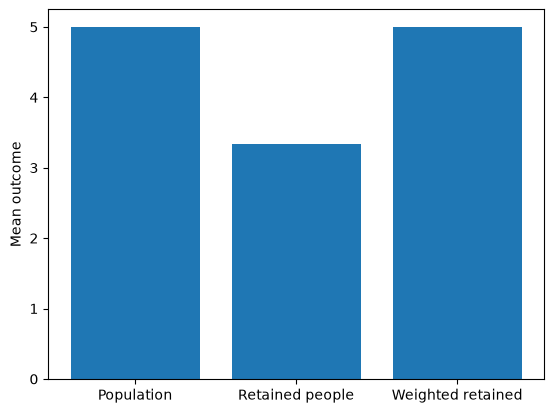

In [2]:
stratum = np.repeat([0, 1], 100)
y = 10.0 * stratum
retention_probability = np.where(stratum == 0, 1.0, 0.5)
keep = (stratum == 0) | ((np.arange(200) % 2) == 0)
weights = 1 / retention_probability[keep]
complete_case = y[keep].mean()
weighted = np.average(y[keep], weights=weights)
assert np.isclose(complete_case, 10 / 3)
assert np.isclose(weighted, y.mean())
print('Population / retained / weighted:', y.mean(), complete_case, weighted)
plt.bar(['Population', 'Retained people', 'Weighted retained'], [y.mean(), complete_case, weighted])
plt.ylabel('Mean outcome'); plt.show()

## Supervise the AI, then transfer the idea

**AI prompt:** “Audit this table before modelling. Identify independent people and retained runs; state whether aggregation changes the estimand. Explain the retention-weight assumptions. Give a short snippet reporting exclusions by stratum and preserve missing values until a policy is justified.”

**Deliberate mistake:** replace missing high-stratum outcomes by zero and call the restored row count a restored sample. Explain why a fabricated value adds no evidence. Then set high-stratum retention probability to zero and ask why weighting cannot repair positivity failure. For real imaging, retain a participant/run/visit/site dictionary, report recruitment and QC flow separately, and consider sensitivity analyses for plausible missingness mechanisms. Cluster-aware standard errors or multilevel models may be needed when individuals share families or sites. Deliver the population definition, observed-sample definition, and a justified aggregation policy; these belong in the preregistration before results are inspected.

## Answer key — read after your own explanation

The mean row is 2.5, while the equal-person mean is 4/3. Complete-case selection produces 3.333; inverse-probability weighting restores five only because retention depends on the fully observed stratum with known positive probabilities. MAR is conditional and not empirically guaranteed by fitting a regression. Repeating the existing rows does not increase independent participants. More precise person-level estimation and larger population sampling are different improvements.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [MIT 9.07 schedule, sampling/probability and estimation](https://ocw.mit.edu/courses/9-07-statistics-for-brain-and-cognitive-science-fall-2016/pages/syllabus/); [DartBrains Group Analysis](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Group_Analysis.ipynb) for the hierarchy of observations; [Lazic on pseudoreplication](https://pmc.ncbi.nlm.nih.gov/articles/PMC2817684/). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
